# RTB Performance Analysis

This notebook walks through the analysis of RTB campaign performance data.
The goal is not just to answer the questions, but to show the thinking behind each step,
from raw data treatment to actionable insights.

## Dataset
- **Source:** RTB client performance data
- **Period:** August to December 2024
- **Format:** Excel file with daily aggregated metrics

## Structure
1. Data loading and treatment
2. Metric calculations — CTR, CPC, CR, ROAS, AOV, Share
3. Is RTB delivering real value?
4. Consolidated diagnosis
5. Forecast methodology

## Setup

Loading the libraries 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# keeping the output clean
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

## 1. Data Loading & Treatment

Loading the raw data and taking a first look before jumping into the analysis.
The dataset covers 335 days of daily aggregated metrics for an RTB client,
running from January to November 2025.

One thing caught my attention right away: the Date column had mixed types, 
some values came through as datetime and others as Excel serial numbers. 
Used `pd.to_datetime` with `errors='coerce'` to fix that, which also flagged 
1 row with an unparseable date that we'll drop before moving forward.

In [11]:
# loading the dataset
df = pd.read_excel('../data/da_dataset.xlsx', sheet_name='data')

# fixing the date column — mix of datetime and serial values coming from Excel
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# quick look at what we're working with
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nDate range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

df.head()




Shape: 335 rows x 14 columns

Date range: 2025-01-01 to 2025-11-30

Missing values per column:
Date                                           1
Imps                                           0
Clicks                                         0
CTR                                          335
Cost (BRL)                                     0
CPC                                          335
RTB attributed conversions                     0
CR                                           335
ROAS (RTB)                                   335
RTB attributed Conversions value (BRL)         0
Average order value                          335
Total number of conversions - client site      0
Share of conversions (%)                     335
Total number of tags fired - client site       0
dtype: int64


,Date,Imps,Clicks,CTR,Cost (BRL),CPC,RTB attributed conversions,CR,ROAS (RTB),RTB attributed Conversions value (BRL),Average order value,Total number of conversions - client site,Share of conversions (%),Total number of tags fired - client site
0,2025-11-30,656516,7821,NaN,1490.58,NaN,120,NaN,NaN,45050.92,NaN,50919,NaN,26273586
1,2025-11-29,4733481,44896,NaN,22570.73,NaN,578,NaN,NaN,186366.17,NaN,77039,NaN,42539823
2,2025-11-28,3323024,39881,NaN,11675.99,NaN,332,NaN,NaN,106489.84,NaN,34328,NaN,26878304
3,2025-11-27,3670245,31046,NaN,6176.43,NaN,239,NaN,NaN,69955.74,NaN,31014,NaN,22964802
4,2025-11-26,3646934,32185,NaN,6509.76,NaN,184,NaN,NaN,61663.03,NaN,24705,NaN,21124588


In [14]:
# dropping the row with unparseable date
df = df.dropna(subset=['date'])

# sorting by date ascending for the analysis
df = df.sort_values('date').reset_index(drop=True)

# renaming columns to make them easier to work with
df.columns = [
    'date', 'imps', 'clicks', 'ctr', 'cost',
    'cpc', 'rtb_conversions', 'cr', 'roas',
    'rtb_conversion_value', 'aov', 
    'total_conversions', 'share', 'total_tags'
]

print("All good! After treatment:", df.shape)
df.head()




All good! After treatment: (334, 14)


,date,imps,clicks,ctr,cost,cpc,rtb_conversions,cr,roas,rtb_conversion_value,aov,total_conversions,share,total_tags
0,2025-01-01,508660,11795,NaN,1047.64,NaN,59,NaN,NaN,17112.95,NaN,4752,NaN,3709976
1,2025-01-02,1995577,39905,NaN,3450.54,NaN,194,NaN,NaN,48121.23,NaN,12328,NaN,7720396
2,2025-01-03,1488615,30524,NaN,3152.22,NaN,257,NaN,NaN,66784.53,NaN,16720,NaN,9644810
3,2025-01-04,1343505,23533,NaN,3249.06,NaN,223,NaN,NaN,61855.77,NaN,18739,NaN,10380340
4,2025-01-05,1326203,25071,NaN,3156.36,NaN,193,NaN,NaN,52160.38,NaN,17039,NaN,9424658


## 2. Metric Calculations

**The ask:** fill out the blank columns: CTR, CPC, CR, ROAS, AOV and Share.

**My approach:**

One thing worth calling out: the dataset has two different scopes that need to stay separate.
Columns G and J reflect only what RTB delivered, while columns L and N cover the advertiser's 
entire operation. Mixing these up would give wrong numbers, especially on Share and ROAS.

I also took care of the formatting upfront. CTR, CR and Share are expressed as percentages, 
CPC and AOV in BRL, all rounded to 2 decimal places. The idea was to have the data 
ready to use directly in the charts and presentation without needing extra conversions later.



In [25]:
# CTR — clicks over impressions
df['ctr'] = (df['clicks'] / df['imps'] * 100).round(2)

# CPC — average cost per click
df['cpc'] = (df['cost'] / df['clicks']).round(2)

# CR — conversions over clicks
df['cr'] = (df['rtb_conversions'] / df['clicks'] * 100).round(2)

# ROAS — revenue generated per unit of cost
df['roas'] = (df['rtb_conversion_value'] / df['cost']).round(2)

# AOV — average value per conversion
df['aov'] = (df['rtb_conversion_value'] / df['rtb_conversions']).round(2)

# Share — RTB conversions as a fraction of total site conversions
df['share'] = (df['rtb_conversions'] / df['total_conversions'] * 100).round(2)

print("Metrics calculated!")
df.head(10)




Metrics calculated!


,date,imps,clicks,ctr,cost,cpc,rtb_conversions,cr,roas,rtb_conversion_value,aov,total_conversions,share,total_tags
0,2025-01-01,508660,11795,2.32,1047.64,0.09,59,0.50,16.33,17112.95,290.05,4752,1.24,3709976
1,2025-01-02,1995577,39905,2.00,3450.54,0.09,194,0.49,13.95,48121.23,248.05,12328,1.57,7720396
2,2025-01-03,1488615,30524,2.05,3152.22,0.10,257,0.84,21.19,66784.53,259.86,16720,1.54,9644810
3,2025-01-04,1343505,23533,1.75,3249.06,0.14,223,0.95,19.04,61855.77,277.38,18739,1.19,10380340
4,2025-01-05,1326203,25071,1.89,3156.36,0.13,193,0.77,16.53,52160.38,270.26,17039,1.13,9424658
5,2025-01-06,1217481,21740,1.79,2065.62,0.10,131,0.60,17.17,35464.12,270.72,14538,0.90,7821152
6,2025-01-07,1259941,21992,1.75,2031.40,0.09,125,0.57,15.98,32460.49,259.68,13520,0.92,7691352
7,2025-01-08,1383506,23248,1.68,3046.50,0.13,220,0.95,20.06,61126.60,277.85,18464,1.19,9757868
8,2025-01-09,1464143,25335,1.73,3667.01,0.14,219,0.86,17.59,64497.81,294.51,20377,1.07,10646879
9,2025-01-10,1588890,27251,1.72,3945.10,0.14,218,0.80,16.91,66715.25,306.03,19232,1.13,9831788


In [26]:
# overall period summary
summary = pd.DataFrame({
    'Metric': ['CTR (%)', 'CPC (BRL)', 'CR (%)', 'ROAS', 'AOV (BRL)', 'Share (%)'],
    'Average': [
        df['ctr'].mean().round(2),
        df['cpc'].mean().round(2),
        df['cr'].mean().round(2),
        df['roas'].mean().round(2),
        df['aov'].mean().round(2),
        df['share'].mean().round(2)
    ]
})
summary



,Metric,Average
0,CTR (%),1.57
1,CPC (BRL),0.15
2,CR (%),0.81
3,ROAS,16.64
4,AOV (BRL),296.84
5,Share (%),0.95


## 3. Is RTB Delivering Real Value?

**The ask:** analyze the data and write insights about volume (impressions, clicks, 
overall website traffic), CPC, total number of conversions, RTB's share of the website 
and overall traffic. Also identify any seasonality, trends and whether RTB results are stable.

**My approach:**
Instead of looking at each metric in isolation, I want to understand how they connect.
The goal is to find the story behind the numbers.



### Mapping the analysis to the data

Before going into details, a quick map of where each topic comes from:

| Topic | Data source |
|---|---|
| **Volume** (impressions, clicks, website traffic) | `imps`, `clicks`, `total_tags` |
| **CPC** | `cpc` |
| **Total number of conversions** | `total_conversions` |
| **RTB's share of the website** | `share` |
| **Overall traffic of the advertiser** | `total_tags` |

Two things to note:

`total_tags` appears in both Volume and Overall traffic, but the angle is different. 
In Volume, it sits with impressions and clicks to show the campaign side. In Overall 
traffic, it's looked at alone to understand the site's behavior.





### 3.1 Volume - Impressions, Clicks and Website Traffic

Starting with the basics: how much volume did the campaign generate and how did 
the site behave alongside



In [27]:
# descriptive stats for volume metrics
volume_stats = df[['imps', 'clicks', 'total_tags']].describe().round(2)
volume_stats

,imps,clicks,total_tags
count,334.00,334.00,334.00
mean,1292177.09,19977.83,12089893.27
std,563058.12,8245.59,3454784.48
min,304035.00,5769.00,3709976.00
25%,919617.75,14102.25,9870114.75
50%,1217325.50,18599.00,11675630.50
75%,1549447.25,25185.25,13421327.00
max,4733481.00,63227.00,42539823.00


**A few things stand out from the numbers:**

Impressions and clicks change a lot through the year. Impressions go up to 4.7M, while 
the daily average is 1.3M. Clicks go from 5.7K to 63K on the highest day. This points 
to either strong seasonality or specific high investment days.

The site itself (`total_tags`) is more stable. It ranges from 3.7M to 42.5M, but the 
spread is smaller compared to its average of 12M.

Average daily traffic is around 12M tags, which looks like a solid baseline for the year.



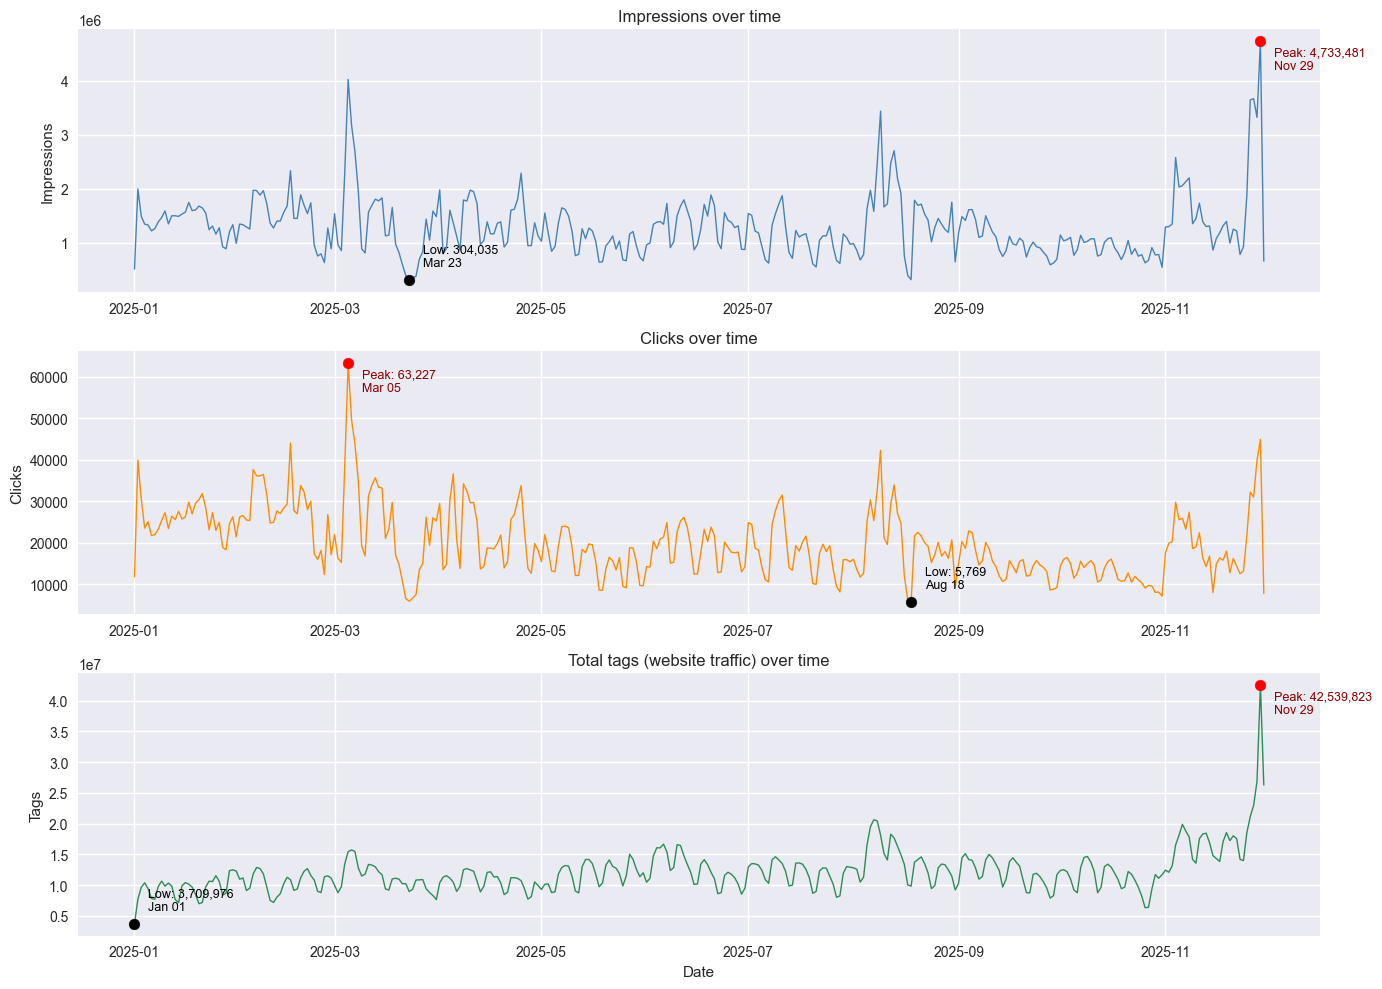

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

metrics = [
    ('imps', 'Impressions over time', 'steelblue', 'Impressions'),
    ('clicks', 'Clicks over time', 'darkorange', 'Clicks'),
    ('total_tags', 'Total tags (website traffic) over time', 'seagreen', 'Tags'),
]

for i, (col, title, color, ylabel) in enumerate(metrics):
    axes[i].plot(df['date'], df[col], color=color, linewidth=1)
    axes[i].set_title(title)
    axes[i].set_ylabel(ylabel)
    
    # marking the peak
    peak_idx = df[col].idxmax()
    peak_date = df.loc[peak_idx, 'date']
    peak_value = df.loc[peak_idx, col]
    axes[i].scatter(peak_date, peak_value, color='red', s=60, zorder=5)
    axes[i].annotate(
        f'Peak: {peak_value:,.0f}\n{peak_date.strftime("%b %d")}',
        xy=(peak_date, peak_value),
        xytext=(10, -20),
        textcoords='offset points',
        fontsize=9,
        color='darkred'
    )
    
    # marking the low
    low_idx = df[col].idxmin()
    low_date = df.loc[low_idx, 'date']
    low_value = df.loc[low_idx, col]
    axes[i].scatter(low_date, low_value, color='black', s=60, zorder=5)
    axes[i].annotate(
        f'Low: {low_value:,.0f}\n{low_date.strftime("%b %d")}',
        xy=(low_date, low_value),
        xytext=(10, 10),
        textcoords='offset points',
        fontsize=9,
        color='black'
    )

axes[2].set_xlabel('Date')
plt.tight_layout()
plt.show()



**What the chart reveals:**

The biggest peak for impressions and website traffic happens on November 29. Black 
Friday pushed impressions to 4.7M and total tags to 42.5M, both well above the daily 
averages of 1.3M and 12M. The campaign and the site moved together that day.

Clicks tell a different story. The peak was March 5 (63K), not November. Impressions 
in March were close to peak weeks in November, but November had fewer clicks. Early 
sign that CTR may have dropped during the year.

The impressions low on March 23 also caught my attention: only 304K, against a daily 
average of 1.3M. Looks like a campaign pause or technical issue.

The most important finding is in the bottom chart. Total tags shows a clear upward 
tren






In [41]:
# adding a quarter column to compare all four periods
df['quarter'] = df['date'].dt.to_period('Q')

quarterly = df.groupby('quarter')[['imps', 'clicks', 'total_tags']].mean().round(0)
quarterly



,imps,clicks,total_tags
quarter,,,
2025Q1,1400701.00,25779.00,10319923.00
2025Q2,1247705.00,18903.00,11632210.00
2025Q3,1216369.00,17734.00,12632967.00
2025Q4,1312737.00,16407.00,14565037.00


In [40]:
# calculating the quarter-over-quarter and year-end variation
quarterly = df.groupby('quarter')[['imps', 'clicks', 'total_tags']].mean().round(0)

# variation from Q1 to Q4
variation = {
    'Impressions': (quarterly.loc['2025Q4', 'imps'] / quarterly.loc['2025Q1', 'imps'] - 1) * 100,
    'Clicks': (quarterly.loc['2025Q4', 'clicks'] / quarterly.loc['2025Q1', 'clicks'] - 1) * 100,
    'Total tags': (quarterly.loc['2025Q4', 'total_tags'] / quarterly.loc['2025Q1', 'total_tags'] - 1) * 100,
}

print("Variation Q1 → Q4 (daily averages):")
for metric, value in variation.items():
    print(f"  {metric}: {value:+.1f}%")




Variation Q1 → Q4 (daily averages):
  Impressions: -6.3%
  Clicks: -36.4%
  Total tags: +41.1%


**Quantifying the growth gap:**

Quarterly daily averages give a clearer view than just comparing Q1 and Q4:

| Quarter | Impressions | Clicks | Total Tags |
|---|---|---|---|
| Q1 | 1.4M | 25.8K | 10.3M |
| Q2 | 1.25M | 18.9K | 11.6M |
| Q3 | 1.22M | 17.7K | 12.6M |
| Q4 | 1.31M | 16.4K | 14.6M |

Clicks dropped every quarter, from 25.8K in Q1 to 16.4K in Q4, a 36% decline. Total 
tags went the other way, growing from 10.3M to 14.6M, a 41% increase.

Impressions stayed stable, with only a 6% drop. They followed a "valley" shape, going 
down until Q3 and recovering in Q4, likely from Black Friday investment.

The gap between site growth and campaign engagement is not a sudden change. It's a 
slow drift across every quarter.



**In short:** the site is growing on its own, but the campaign's engagement is shrinking. 
Two trends moving in opposite directions across the year.


### 3.2 CPC - Cost per Click

Looking at how much the campaign paid per click during the year.

In [34]:
# cpc stats
df['cpc'].describe().round(2)

count   334.00
mean      0.15
std       0.04
min       0.07
25%       0.12
50%       0.14
75%       0.17
max       0.50
Name: cpc, dtype: float64

In [35]:
df.groupby('quarter')['cpc'].mean().round(2)


quarter
2025Q1   0.14
2025Q2   0.17
2025Q3   0.14
2025Q4   0.13
Freq: Q-DEC, Name: cpc, dtype: float64

In [36]:
df.groupby('quarter')['cost'].sum().round(2)

quarter
2025Q1   326203.89
2025Q2   293486.00
2025Q3   243270.59
2025Q4   152591.18
Freq: Q-DEC, Name: cost, dtype: float64

In [37]:
df.groupby('quarter')['ctr'].mean().round(2)

quarter
2025Q1   1.87
2025Q2   1.51
2025Q3   1.49
2025Q4   1.31
Freq: Q-DEC, Name: ctr, dtype: float64

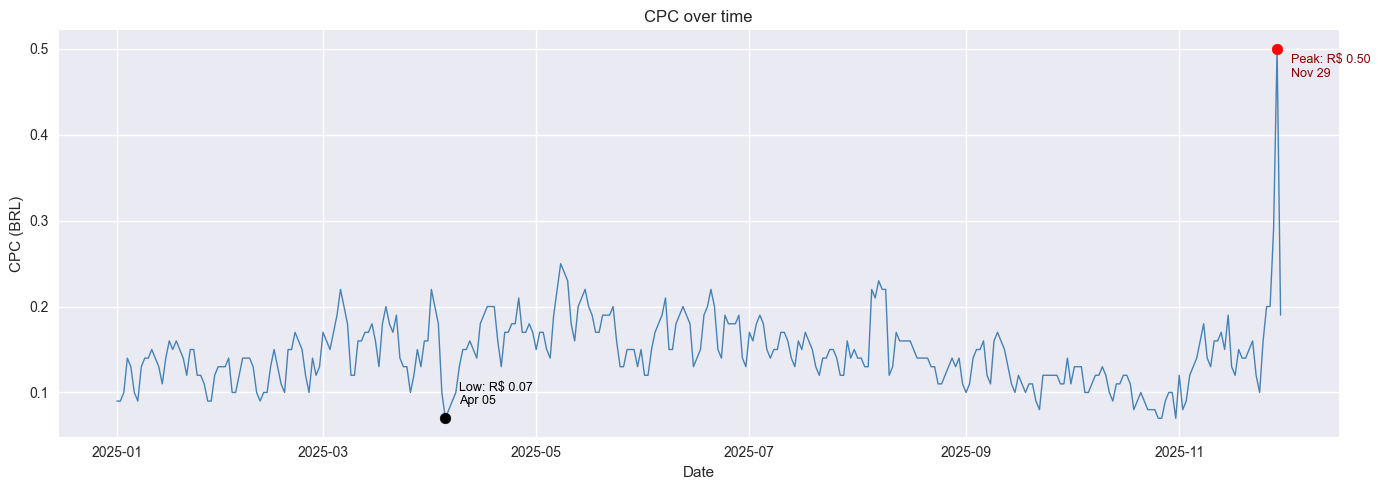

In [38]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['date'], df['cpc'], color='steelblue', linewidth=1)
ax.set_title('CPC over time')
ax.set_ylabel('CPC (BRL)')
ax.set_xlabel('Date')

# marking the peak
peak_idx = df['cpc'].idxmax()
peak_date = df.loc[peak_idx, 'date']
peak_value = df.loc[peak_idx, 'cpc']
ax.scatter(peak_date, peak_value, color='red', s=60, zorder=5)
ax.annotate(
    f'Peak: R$ {peak_value:.2f}\n{peak_date.strftime("%b %d")}',
    xy=(peak_date, peak_value),
    xytext=(10, -20),
    textcoords='offset points',
    fontsize=9,
    color='darkred'
)

# marking the low
low_idx = df['cpc'].idxmin()
low_date = df.loc[low_idx, 'date']
low_value = df.loc[low_idx, 'cpc']
ax.scatter(low_date, low_value, color='black', s=60, zorder=5)
ax.annotate(
    f'Low: R$ {low_value:.2f}\n{low_date.strftime("%b %d")}',
    xy=(low_date, low_value),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9,
    color='black'
)

plt.tight_layout()
plt.show()

In [42]:
# variation from Q1 to Q4 for cpc, cost and ctr
variation = {
    'CPC': (df[df['quarter'] == '2025Q4']['cpc'].mean() / df[df['quarter'] == '2025Q1']['cpc'].mean() - 1) * 100,
    'Total cost': (df[df['quarter'] == '2025Q4']['cost'].sum() / df[df['quarter'] == '2025Q1']['cost'].sum() - 1) * 100,
    'CTR': (df[df['quarter'] == '2025Q4']['ctr'].mean() / df[df['quarter'] == '2025Q1']['ctr'].mean() - 1) * 100,
}

print("Variation Q1 → Q4:")
for metric, value in variation.items():
    print(f"  {metric}: {value:+.1f}%")


Variation Q1 → Q4:
  CPC: -4.5%
  Total cost: -53.2%
  CTR: -29.8%


**The takeaway:**

CPC stayed pretty stable during the year. Most days were between R$ 0.10 and R$ 0.20.

The peak on November 29 (R$ 0.50) happened on Black Friday, the same day impressions 
and site traffic hit their highs. Competition for inventory goes up during big retail 
events, pushing CPC higher.

The low on April 5 (R$ 0.07) was the opposite: a day with less competition or cheaper 
inventory. From October on, CPC got more volatile, probably from the Black Friday 
pressure building up.

**Quarterly CPC and total cost:**

| Quarter | CPC | Total Cost |
|---|---|---|
| Q1 |  0.14 |  326,204 |
| Q2 |  0.17 |  293,486 |
| Q3 |  0.14 |  243,271 |
| Q4 |  0.13 |  152,591 |

CPC didn't grow. It dropped 7% from Q1 to Q4. But total cost dropped 53%.

**Quarterly CTR:**

| Quarter | CTR |
|---|---|
| Q1 | 1.87% |
| Q2 | 1.51% |
| Q3 | 1.49% |
| Q4 | 1.31% |

CTR dropped 30% from Q1 to Q4. The lower number of clicks came from two things: less 
investment (fewer impressions bought) and lower engagement.

The drop in clicks wasn't because clicks got more expensive. What changed was the total 
investment, which fell from R$ 326K to R$ 152K. The data doesn't show why. Could be a 
budget cut or something operational. We can confirm the fact, but 
not the reason.




### 3.3 Conversions - RTB and Total

Looking at how conversions behaved during the year



In [43]:

df[['rtb_conversions', 'total_conversions']].describe().round(2)


,rtb_conversions,total_conversions
count,334.00,334.00
mean,162.35,16996.58
std,80.47,5700.76
min,24.00,4752.00
25%,104.25,13693.75
50%,149.50,16439.50
75%,213.75,18896.75
max,578.00,77039.00


In [44]:

df.groupby('quarter')[['rtb_conversions', 'total_conversions']].mean().round(0)

,rtb_conversions,total_conversions
quarter,,
2025Q1,197.00,15582.00
2025Q2,179.00,16474.00
2025Q3,144.00,17047.00
2025Q4,115.00,19786.00


In [45]:
variation = {
    'RTB conversions': (df[df['quarter'] == '2025Q4']['rtb_conversions'].mean() / df[df['quarter'] == '2025Q1']['rtb_conversions'].mean() - 1) * 100,
    'Total conversions': (df[df['quarter'] == '2025Q4']['total_conversions'].mean() / df[df['quarter'] == '2025Q1']['total_conversions'].mean() - 1) * 100,
}

print("Variation Q1 → Q4:")
for metric, value in variation.items():
    print(f"  {metric}: {value:+.1f}%")

Variation Q1 → Q4:
  RTB conversions: -41.8%
  Total conversions: +27.0%


In [47]:
# black friday day metrics vs Q4 average
black_friday = df[df['date'] == '2025-11-29']
q4_avg = df[df['quarter'] == '2025Q4']

print("Black Friday (Nov 29) vs Q4 daily average:")
print(f"  RTB conversions:   {black_friday['rtb_conversions'].values[0]:.0f} vs {q4_avg['rtb_conversions'].mean():.0f}")
print(f"  Total conversions: {black_friday['total_conversions'].values[0]:.0f} vs {q4_avg['total_conversions'].mean():.0f}")

# calculating the multiplier
rtb_mult = black_friday['rtb_conversions'].values[0] / q4_avg['rtb_conversions'].mean()
total_mult = black_friday['total_conversions'].values[0] / q4_avg['total_conversions'].mean()

print(f"\nRTB multiplier:   {rtb_mult:.1f}x")
print(f"Total multiplier: {total_mult:.1f}x")


Black Friday (Nov 29) vs Q4 daily average:
  RTB conversions:   578 vs 115
  Total conversions: 77039 vs 19786

RTB multiplier:   5.0x
Total multiplier: 3.9x


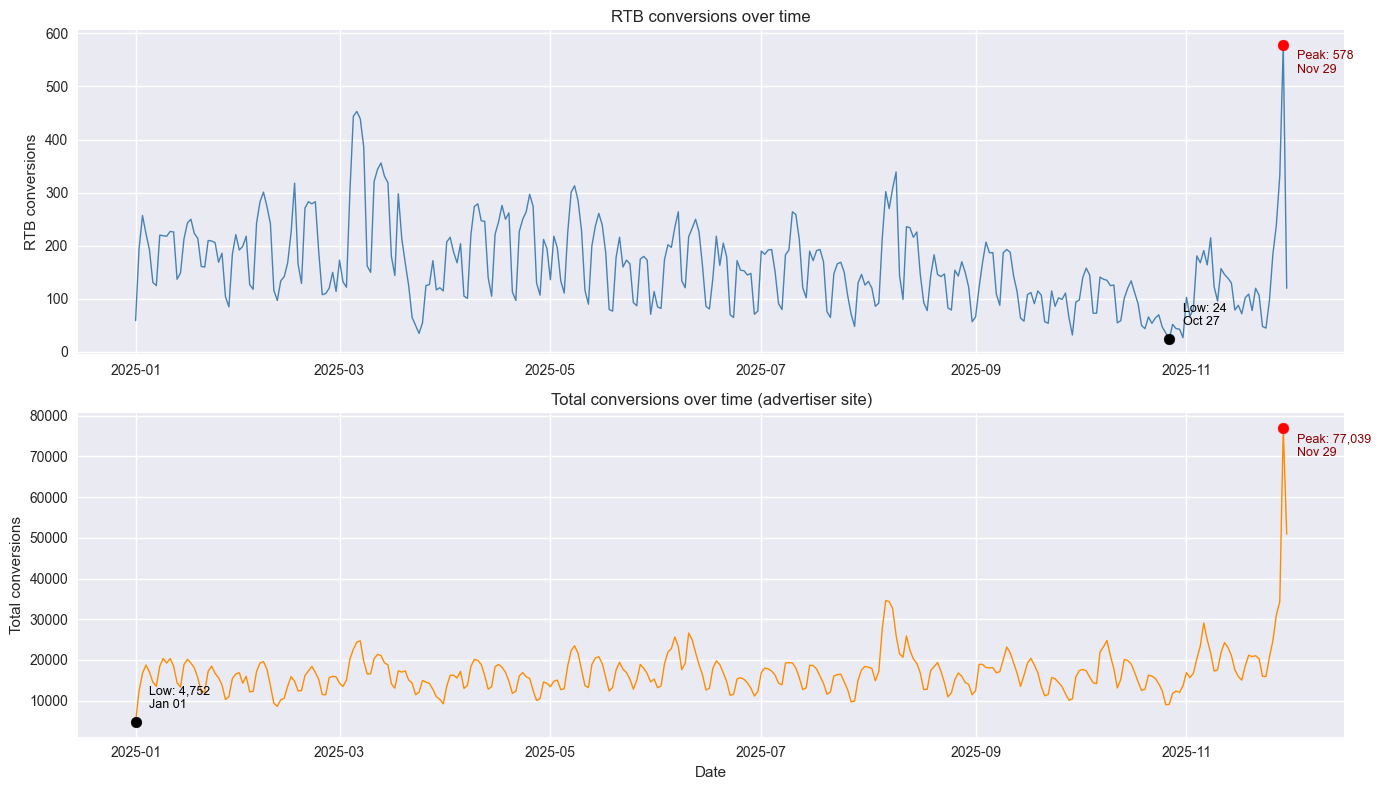

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# rtb conversions
axes[0].plot(df['date'], df['rtb_conversions'], color='steelblue', linewidth=1)
axes[0].set_title('RTB conversions over time')
axes[0].set_ylabel('RTB conversions')

peak_idx = df['rtb_conversions'].idxmax()
peak_date = df.loc[peak_idx, 'date']
peak_value = df.loc[peak_idx, 'rtb_conversions']
axes[0].scatter(peak_date, peak_value, color='red', s=60, zorder=5)
axes[0].annotate(
    f'Peak: {peak_value:.0f}\n{peak_date.strftime("%b %d")}',
    xy=(peak_date, peak_value),
    xytext=(10, -20),
    textcoords='offset points',
    fontsize=9,
    color='darkred'
)

low_idx = df['rtb_conversions'].idxmin()
low_date = df.loc[low_idx, 'date']
low_value = df.loc[low_idx, 'rtb_conversions']
axes[0].scatter(low_date, low_value, color='black', s=60, zorder=5)
axes[0].annotate(
    f'Low: {low_value:.0f}\n{low_date.strftime("%b %d")}',
    xy=(low_date, low_value),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9,
    color='black'
)

# total conversions
axes[1].plot(df['date'], df['total_conversions'], color='darkorange', linewidth=1)
axes[1].set_title('Total conversions over time (advertiser site)')
axes[1].set_ylabel('Total conversions')
axes[1].set_xlabel('Date')

peak_idx = df['total_conversions'].idxmax()
peak_date = df.loc[peak_idx, 'date']
peak_value = df.loc[peak_idx, 'total_conversions']
axes[1].scatter(peak_date, peak_value, color='red', s=60, zorder=5)
axes[1].annotate(
    f'Peak: {peak_value:,.0f}\n{peak_date.strftime("%b %d")}',
    xy=(peak_date, peak_value),
    xytext=(10, -20),
    textcoords='offset points',
    fontsize=9,
    color='darkred'
)

low_idx = df['total_conversions'].idxmin()
low_date = df.loc[low_idx, 'date']
low_value = df.loc[low_idx, 'total_conversions']
axes[1].scatter(low_date, low_value, color='black', s=60, zorder=5)
axes[1].annotate(
    f'Low: {low_value:,.0f}\n{low_date.strftime("%b %d")}',
    xy=(low_date, low_value),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9,
    color='black'
)

plt.tight_layout()
plt.show()

**The takeaway:**

RTB and total conversions moved in opposite directions, same pattern we saw with 
volume and clicks.

RTB conversions dropped 41.8% from Q1 to Q4 (197 to 115 per day). Total conversions 
grew 27% in the same period (15,582 to 19,786).

The peak on November 29 appears in both charts: 578 RTB conversions and 77,039 total 
conversions. RTB grew 5.0x its Q4 daily average that day, total grew 3.9x.

Black Friday drives strong numbers across every channel, so this peak alone doesn't 
prove the campaign is healthy. It just shows the channel can still scale when 
investment is there.

The low of 24 RTB conversions on October 27 caught my attention. Right before Black 
Friday, RTB was at one of the lowest points of the year. Could be a pause, low 
investment days.

The funnel cascade is now complete:

- Investment dropped 53%
- Impressions dropped 6%
- CTR dropped 30%
- Clicks dropped 36%
- RTB conversions dropped 42%

Each step lost more than the previous one. Meanwhile, the advertiser's site grew 
across every metric. Other traffic sources made up for the RTB drop.

So the advertiser is growing, but RTB is losing space in their channel mix.




### 3.4 RTB Share - How much of the site's conversions come from RTB

Looking at the slice of total site conversions that came specifically from RTB. 




In [48]:


df['share'].describe().round(2)

count   334.00
mean      0.95
std       0.38
min       0.20
25%       0.65
50%       0.94
75%       1.21
max       2.19
Name: share, dtype: float64

In [49]:
df.groupby('quarter')['share'].mean().round(2)


quarter
2025Q1   1.23
2025Q2   1.07
2025Q3   0.82
2025Q4   0.55
Freq: Q-DEC, Name: share, dtype: float64

In [50]:
share_q1 = df[df['quarter'] == '2025Q1']['share'].mean()
share_q4 = df[df['quarter'] == '2025Q4']['share'].mean()
variation = (share_q4 / share_q1 - 1) * 100

print(f"Share Q1: {share_q1:.2f}%")
print(f"Share Q4: {share_q4:.2f}%")
print(f"Variation Q1 → Q4: {variation:+.1f}%")

Share Q1: 1.23%
Share Q4: 0.55%
Variation Q1 → Q4: -55.1%


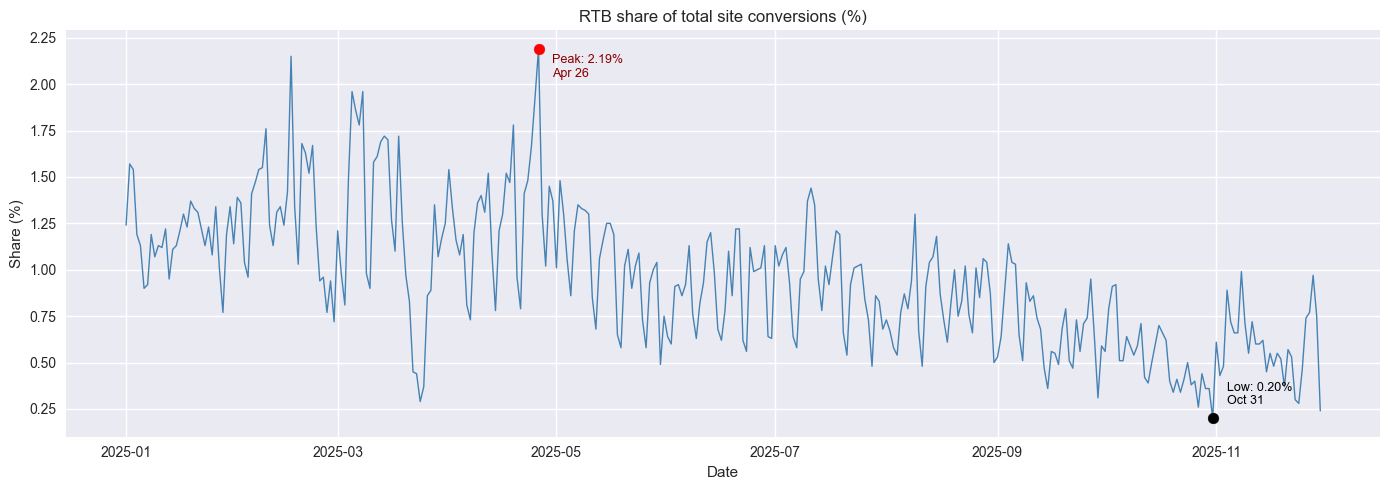

In [51]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['date'], df['share'], color='steelblue', linewidth=1)
ax.set_title('RTB share of total site conversions (%)')
ax.set_ylabel('Share (%)')
ax.set_xlabel('Date')

# marking peak
peak_idx = df['share'].idxmax()
peak_date = df.loc[peak_idx, 'date']
peak_value = df.loc[peak_idx, 'share']
ax.scatter(peak_date, peak_value, color='red', s=60, zorder=5)
ax.annotate(
    f'Peak: {peak_value:.2f}%\n{peak_date.strftime("%b %d")}',
    xy=(peak_date, peak_value),
    xytext=(10, -20),
    textcoords='offset points',
    fontsize=9,
    color='darkred'
)

# marking low
low_idx = df['share'].idxmin()
low_date = df.loc[low_idx, 'date']
low_value = df.loc[low_idx, 'share']
ax.scatter(low_date, low_value, color='black', s=60, zorder=5)
ax.annotate(
    f'Low: {low_value:.2f}%\n{low_date.strftime("%b %d")}',
    xy=(low_date, low_value),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9,
    color='black'
)

plt.tight_layout()
plt.show()


**The takeaway:**

RTB share dropped 55.1% over the year, from 1.23% in Q1 to 0.55% in Q4. The decline 
was consistent across all quarters.

The peak of 2.19% on April 26 was a day where RTB performed well and the site had 
lower volume. The low of 0.20% on October 31 was the worst day of the year.

Even with RTB hitting its yearly volume peak on Black Friday (578 conversions), the 
share that day wasn't the highest. The site grew so much that strong RTB days got 
diluted.

Share dropped more than any other metric because the math compounds: RTB conversions 
falling while total conversions grew. Both forces pushing the ratio down.

RTB lost relevance in the advertiser's mix during the year. Not because it stopped 
working, but because it lost weight against everything else.